In [ ]:
from google.colab import files
files.upload() #< upload obsKB_stageB_seed0_20260318_094210.npz

In [ ]:
import numpy as np
import math

# ============================================================
#  DRIFT ON THE SQUARE
# ============================================================

def drift_on_square(u, v):
    """
    Drift field on the intrinsic square coordinates.
    """
    return np.array([
        1+.5*np.cos(u/2)*np.sin(v),
        .5*np.sin(2*v)
    ])


# ============================================================
#  SDE SIMULATION ON THE SQUARE
# ============================================================

def SDE_on_square(N, Delta, x0):
    """
    Simulate an SDE on the square with unit diffusion
    and prescribed drift.

    Parameters
    ----------
    N : int
        Number of time steps.
    Delta : float
        Time step size.
    x0 : (2,) array
        Initial point.

    Returns
    -------
    SDE : (N+1, 2) array
        Simulated trajectory.
    """
    SDE = np.zeros((N + 1, 2))
    SDE[0] = x0
    curr_point = x0

    for i in range(N):
        dW = np.random.randn(2) / np.sqrt(2)
        drift = drift_on_square(curr_point[0], curr_point[1])
        increment = np.sqrt(2 * Delta) * dW + Delta * drift
        curr_point = curr_point + increment
        SDE[i + 1] = curr_point

    return SDE


# ============================================================
#  KLEIN BOTTLE EMBEDDING
# ============================================================

def embed_klein_bottle(time_series, a, r):
    """
    Embed intrinsic coordinates (u, v) into R^4 Klein bottle.
    """
    KB_embed = np.zeros((len(time_series), 4))

    u = time_series[:, 0]
    v = time_series[:, 1]

    KB_embed[:, 0] = np.cos(u) * (a + r * np.cos(v))
    KB_embed[:, 1] = np.sin(u) * (a + r * np.cos(v))
    KB_embed[:, 2] = r * np.cos(u / 2) * np.sin(v)
    KB_embed[:, 3] = r * np.sin(u / 2) * np.sin(v)

    return KB_embed


# ============================================================
#  DIFFERENTIAL GEOMETRY HELPERS
# ============================================================

def klein_jacobian(u, v, a, r):
    Ju = np.array([
        -np.sin(u) * (a + r * np.cos(v)),
         np.cos(u) * (a + r * np.cos(v)),
        -0.5 * r * np.sin(u / 2) * np.sin(v),
         0.5 * r * np.cos(u / 2) * np.sin(v)
    ])

    Jv = np.array([
        -r * np.cos(u) * np.sin(v),
        -r * np.sin(u) * np.sin(v),
         r * np.cos(u / 2) * np.cos(v),
         r * np.sin(u / 2) * np.cos(v)
    ])

    return np.column_stack((Ju, Jv))  # shape (4, 2)


def pullback_to_square(w, u, v, a, r, eps=1e-10):
    J = klein_jacobian(u, v, a, r)
    G = J.T @ J + eps * np.eye(2)
    return np.linalg.solve(G, J.T @ w)


def true_diffusion(u, v, a, r):
    """
    True diffusion matrix in R^4 induced by the embedding.
    """
    J = klein_jacobian(u, v, a, r)
    return J @ J.T


def klein_ito_drift(u, v, a, r):
    """
    (1/2)(∂_uu Φ + ∂_vv Φ) for the Klein bottle embedding.
    """
    term = np.zeros(4)

    # ∂_uu Φ
    term[0] += -np.cos(u) * (a + r * np.cos(v))
    term[1] += -np.sin(u) * (a + r * np.cos(v))
    term[2] += -0.25 * r * np.cos(u / 2) * np.sin(v)
    term[3] += -0.25 * r * np.sin(u / 2) * np.sin(v)

    # ∂_vv Φ
    term[0] += -r * np.cos(u) * np.cos(v)
    term[1] += -r * np.sin(u) * np.cos(v)
    term[2] += -r * np.cos(u / 2) * np.sin(v)
    term[3] += -r * np.sin(u / 2) * np.sin(v)

    return 0.5 * term


def true_ambient_drift(u, v, a, r):
    """
    True ambient drift in R^4 from Ito's lemma.
    """
    J = klein_jacobian(u, v, a, r)
    b = drift_on_square(u, v)
    return J @ b + klein_ito_drift(u, v, a, r)






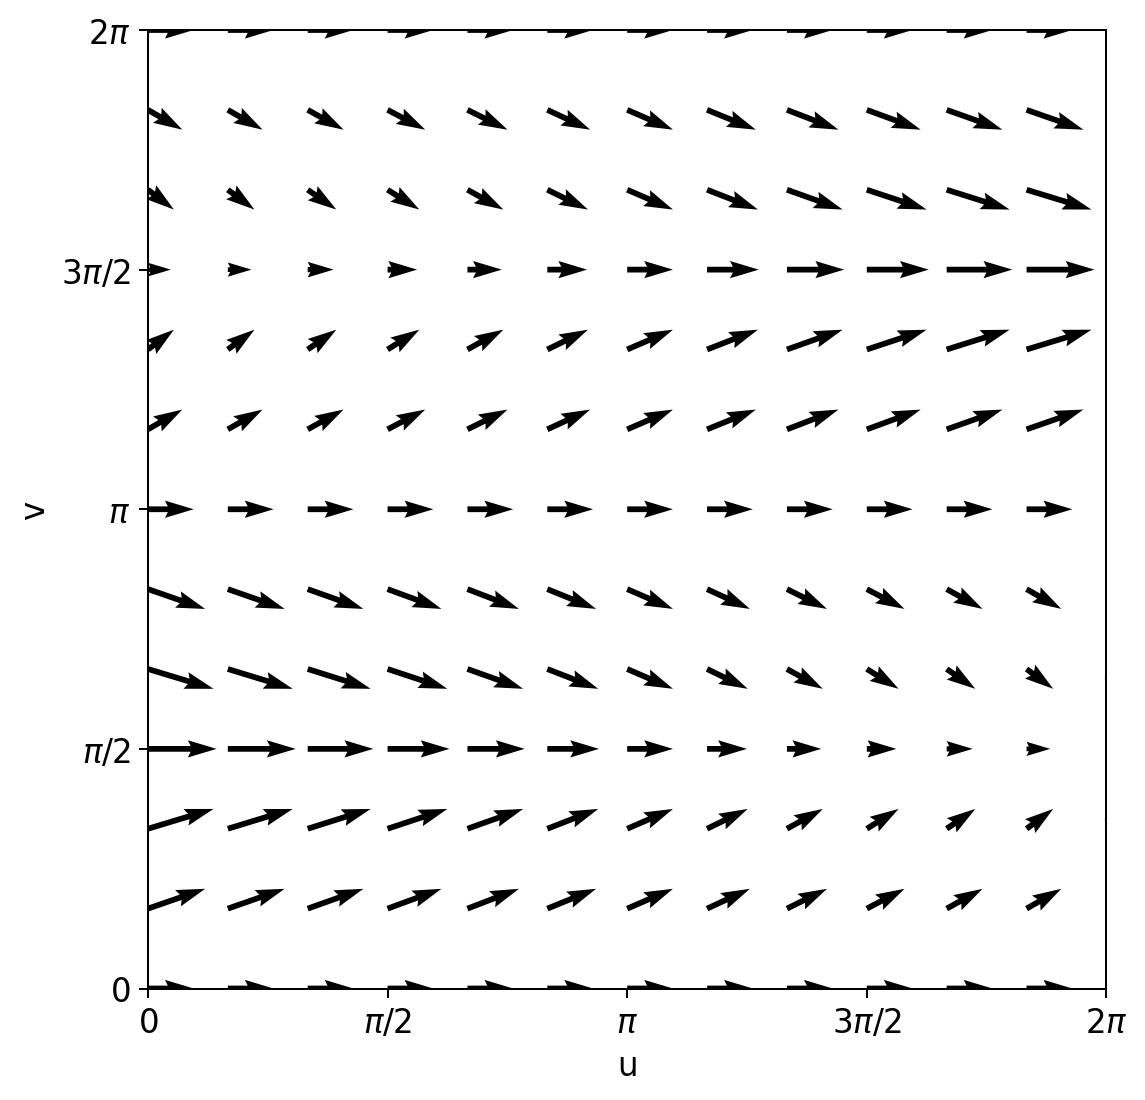

Max speed on grid = 1.5
GAIN used = 0.3 (so max arrow length ≈ 0.45 axis units)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Drift field on the square parameter domain.
def drift_on_square(u, v):
    return np.array([
        1 + 0.5*np.cos(u/2)*np.sin(v),
        0.5*np.sin(2*v)
    ])

# Parameter domain and evaluation grid.
TWO_PI = 2*np.pi
u_min, u_max = 0.0, TWO_PI
v_min, v_max = 0.0, TWO_PI

nu, nv = 13, 13
u = np.linspace(u_min, u_max, nu)
v = np.linspace(v_min, v_max, nv)
U, V = np.meshgrid(u, v, indexing="xy")

# Vector field evaluated on the grid.
DU = 1 + 0.5*np.cos(U/2)*np.sin(V)
DV = 0.5*np.sin(2*V)

# Field magnitude, used only to calibrate arrow lengths.
speed = np.sqrt(DU**2 + DV**2)
smax = float(np.max(speed))

# Plot settings.
plt.rcParams.update({
    "figure.dpi": 180,
    "savefig.dpi": 300,
    "font.size": 13,
    "axes.titlesize": 14,
})

fig, ax = plt.subplots(figsize=(7.0, 6.0), constrained_layout=True)

# Target length of the largest arrow in axis units.
MAX_ARROW_LEN = 0.45

# Global rescaling so the maximum arrow length matches MAX_ARROW_LEN.
GAIN = (MAX_ARROW_LEN / (smax + 1e-12))

# Quiver uses data units directly, so arrow lengths remain proportional
# to the rescaled vector magnitudes.
ax.quiver(
    U, V, GAIN*DU, GAIN*DV,
    angles="xy",
    scale_units="xy",
    scale=1.0,
    width=0.006,
    minlength=0.0
)

ax.set_xlabel("u")
ax.set_ylabel("v")
ax.set_xlim(u_min, u_max)
ax.set_ylim(v_min, v_max)
ax.set_aspect("equal")

ticks = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]
ticklabels = [r"$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"]
ax.set_xticks(ticks); ax.set_xticklabels(ticklabels)
ax.set_yticks(ticks); ax.set_yticklabels(ticklabels)

plt.show()

print(f"Max speed on grid = {smax:.6g}")
print(f"GAIN used = {GAIN:.6g} (so max arrow length ≈ {MAX_ARROW_LEN} axis units)")

In [ ]:
# =========================
# Cell 1: Load experiment outputs
# =========================
import numpy as np

# NPZ file produced by the Stage B Klein bottle experiment.
filename = "obsKB_stageB_seed0_20260318_094210.npz"

npz = np.load(filename)

# Projected drift fields at all base points.
# Shapes are (S, B, 4), where
#   S = number of simulations,
#   B = number of base points,
#   4 = ambient dimension of the Klein bottle embedding.
mu_proj_TT_all  = np.asarray(npz["mu_proj_TT"], dtype=float)   # true tangent projector applied to true drift
mu_proj_TE_all  = np.asarray(npz["mu_proj_TE"], dtype=float)   # true tangent projector applied to estimated ambient drift
mu_proj_EE_all  = np.asarray(npz["mu_proj_EE"], dtype=float)   # estimated tangent projector applied to estimated ambient drift
h_used_all      = np.asarray(npz["h_used"], dtype=float)       # kernel bandwidth used at each base point
base_points_all = np.asarray(npz["base_points"], dtype=float)  # square-parameter base points, shape (B, 2)

# Raw ambient Euclidean drift estimator \hat{\mu}_E at all base points.
mu_hat_all = np.asarray(npz["mu_hat"], dtype=float)            # shape (S, B, 4)

# Estimated ambient diffusion matrices at all base points.
pi_hat_all = np.asarray(npz["sigma_hat"], dtype=float)         # shape (S, B, 4, 4)

# Klein bottle embedding parameters, if stored in the file.
a = float(npz["a"]) if "a" in npz.files else None
r = float(npz["r"]) if "r" in npz.files else None

# Simulation averages over the Monte Carlo axis.
# Each average has one entry per base point.
mu_proj_TT_avg_all = np.nanmean(mu_proj_TT_all, axis=0)        # shape (B, 4)
mu_proj_TE_avg_all = np.nanmean(mu_proj_TE_all, axis=0)        # shape (B, 4)
mu_proj_EE_avg_all = np.nanmean(mu_proj_EE_all, axis=0)        # shape (B, 4)
mu_hat_avg_all     = np.nanmean(mu_hat_all, axis=0)            # shape (B, 4)

pi_hat_avg_all     = np.nanmean(pi_hat_all, axis=0)            # shape (B, 4, 4)

# Square coordinates of the base points.
u_bp_all = base_points_all[:, 0]
v_bp_all = base_points_all[:, 1]

print("num_neighbors =", int(np.asarray(npz["num_neighbors"]).item()) if "num_neighbors" in npz.files else "(missing)")
print("Total basepoints (B) =", base_points_all.shape[0])
print("Sims (S) =", mu_proj_TT_all.shape[0])

# Summary of all arrays stored in the NPZ file.
for k in npz.files:
    v = npz[k]
    if hasattr(v, "shape"):
        print(f"{k:20s} shape={v.shape} dtype={v.dtype}")
    else:
        print(f"{k:20s} type={type(v)}")

num_neighbors = 10000
Total basepoints (B) = 10000
Sims (S) = 1
base_points          shape=(10000, 2) dtype=float64
u_min                shape=() dtype=float64
u_max                shape=() dtype=float64
v_min                shape=() dtype=float64
v_max                shape=() dtype=float64
mu_proj_TT           shape=(1, 10000, 4) dtype=float64
mu_proj_TE           shape=(1, 10000, 4) dtype=float64
mu_proj_EE           shape=(1, 10000, 4) dtype=float64
mu_proj_TT_square    shape=(1, 10000, 2) dtype=float64
mu_proj_TE_square    shape=(1, 10000, 2) dtype=float64
mu_proj_EE_square    shape=(1, 10000, 2) dtype=float64
occ_den              shape=(1, 10000) dtype=float64
sigma_hat            shape=(1, 10000, 4, 4) dtype=float64
mu_hat               shape=(1, 10000, 4) dtype=float64
h_used               shape=(1, 10000) dtype=float64
seed                 shape=() dtype=int64
N_full               shape=() dtype=int64
N_eff                shape=() dtype=int64
Delta_full           shape=() dtype

Rectangle (periodic): u∈[2.142,4.142], v∈[5.783,0.5]
Basepoints: total=10000, in_rect=465
Stratified selection: 58 points (<= 324 cells).
Plotting points/arrows: 58 (exactly matched)


/tmp/ipykernel_1380/8365532.py:426: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(


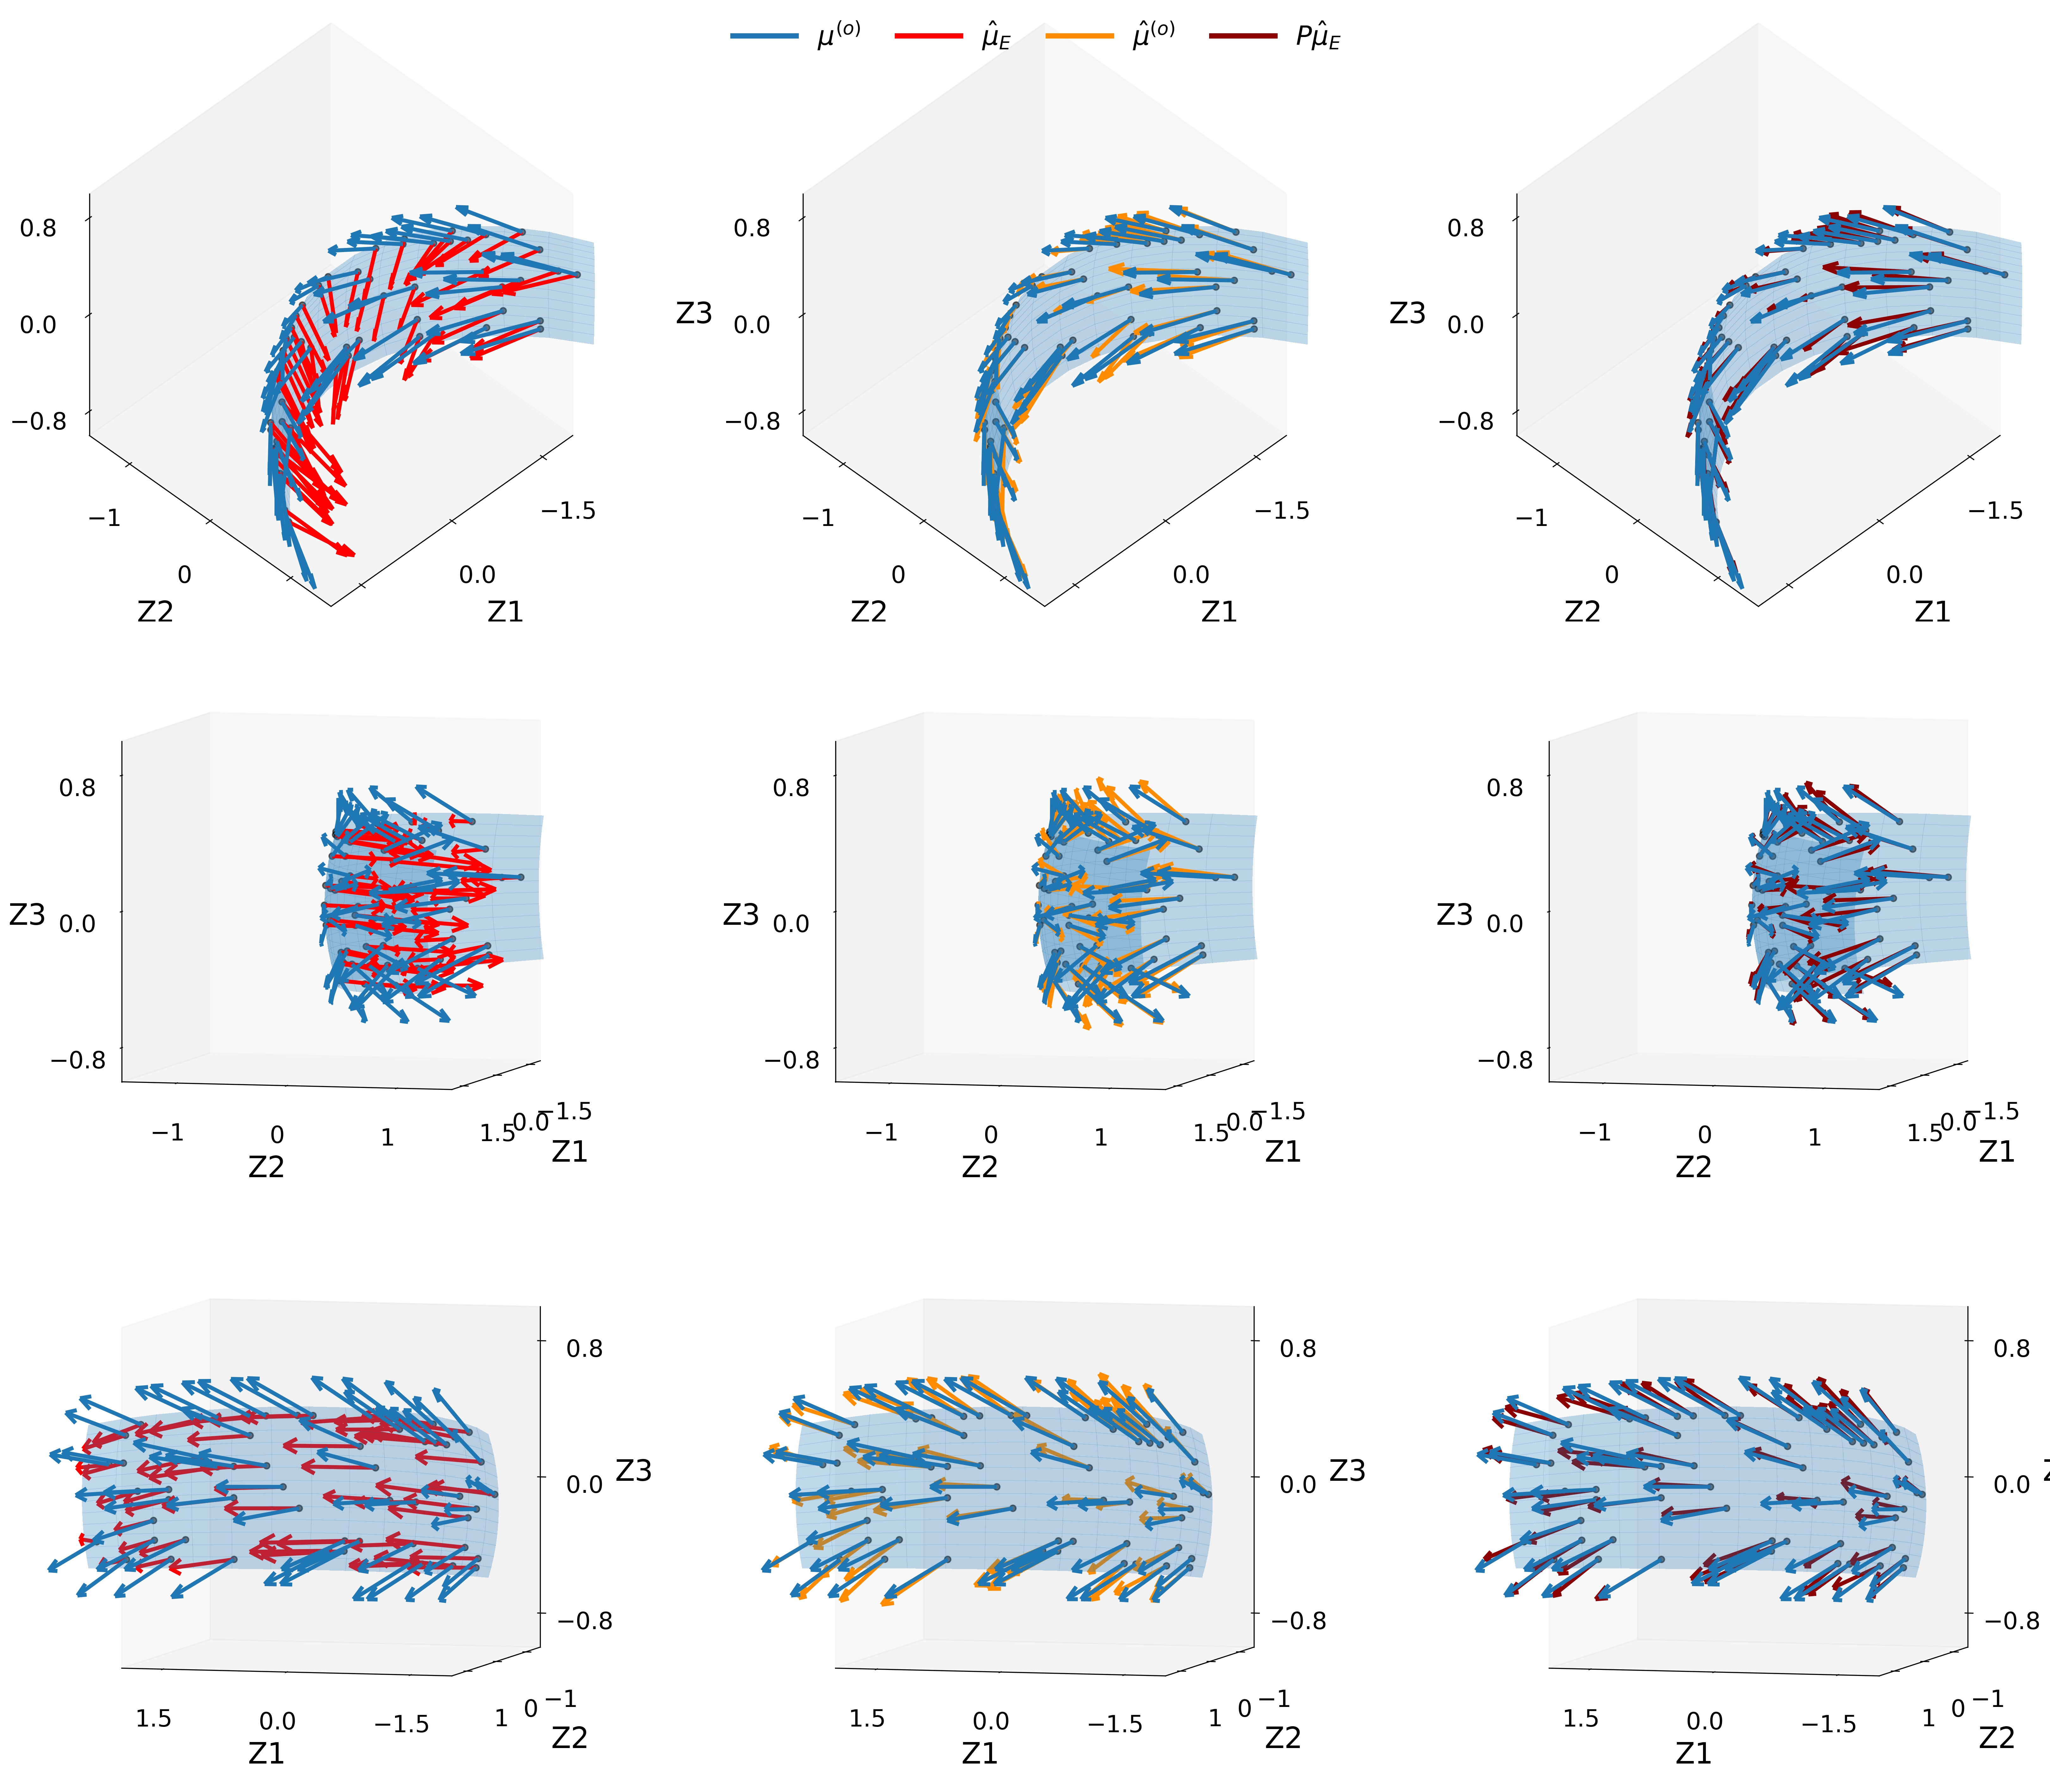

In [ ]:
# ============================================================
# KB local PCA drift visualization
#
# Workflow
#   1. Restrict base points to a rectangular window in square coordinates
#   2. Build a local PCA basis from all base points in the window
#   3. Use one common index set for both scatter points and arrows
#   4. Display three views by three drift estimators
#
# Display conventions
#   - rows correspond to viewing angles
#   - columns correspond to drift estimators
#   - axis labels are Z1, Z2, Z3 in the local PCA coordinates
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# ----------------------------
# Plot styling
# ----------------------------
plt.rcParams["figure.dpi"] = 300
plt.rcParams["savefig.dpi"] = 300
plt.rcParams.update({
    "font.size": 22,
    "axes.titlesize": 24,
    "axes.labelsize": 22,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 20
})

# ----------------------------
# User controls
# ----------------------------
# Window in square coordinates.
USE_NPZ_WINDOW = False
u_min_user, u_max_user = np.pi - 1, np.pi + 1
v_min_user, v_max_user = 2*np.pi - 0.5, 2*np.pi + 0.5

# Camera views for the three display rows.
VIEWS = [
    (45, 45),
    (5, 15),
    (5, 105),
]

# Surface mesh controls.
SURF_N_MAX = 14
SURF_STRIDE = 1
SURF_ALPHA = 0.28

# Arrow appearance.
ARROW_LW = 3.0
ARROW_HEAD = 0.18
ARROW_FRAC = 0.22

# Scatter appearance.
DOT_S = 22
DOT_ALPHA = 0.55

# Point-selection strategy for plotting.
USE_STRATIFIED = True
GRID_N1 = 18
GRID_N2 = 18

# Fallback thinning if stratified selection is disabled.
N_KEEP = 50
THIN_STRIDE = None

# Tick controls.
NBINS_TICKS = 3

# Padding chosen to avoid overlap in 3D panels.
LABELPAD = 30
TICK_PAD = 16

# Display cube in PCA coordinates.
xlim, ylim, zlim = ((-2.0, 2.0), (-1.5, 1.5), (-1.0, 1.0))

# ----------------------------
# Pull arrays from memory
# Expected in memory:
#   base_points_all : (B, 2)
#   mu_hat_all, mu_proj_EE_all, mu_proj_TE_all, mu_proj_TT_all : (S, B, 4)
#   npz, a, r
# ----------------------------
bp_all = np.asarray(base_points_all, dtype=float)          # base points in square coordinates
mu_hat_all_arr = np.asarray(mu_hat_all, dtype=float)       # raw ambient drift estimate
mu_EE_all_arr  = np.asarray(mu_proj_EE_all, dtype=float)   # estimated tangent projection of estimated drift
mu_TE_all_arr  = np.asarray(mu_proj_TE_all, dtype=float)   # true tangent projection of estimated drift
mu_TT_all_arr  = np.asarray(mu_proj_TT_all, dtype=float)   # true tangent projection of true drift

a_val = float(a)
r_val = float(r)

S, B, d = mu_hat_all_arr.shape
if bp_all.shape != (B, 2) or d != 4:
    raise ValueError(
        f"Shape mismatch:\n"
        f"  base_points_all shape={bp_all.shape}, expected ({B},2)\n"
        f"  mu_hat_all shape={mu_hat_all_arr.shape}, expected (S,B,4)\n"
    )

# ----------------------------
# Periodic window restriction
# ----------------------------
TWO_PI = 2.0 * np.pi

def wrap01(x):
    # Wrap angles into [0, 2pi).
    return np.mod(x, TWO_PI)

def in_periodic_interval(x, lo, hi):
    # Membership test for a periodic interval on the circle.
    lo_w = wrap01(lo); hi_w = wrap01(hi)
    if np.isclose(lo_w, hi_w):
        if (hi - lo) >= TWO_PI:
            return np.ones_like(x, dtype=bool), lo_w, hi_w
        return np.isclose(x, lo_w), lo_w, hi_w
    if lo_w <= hi_w:
        return (x >= lo_w) & (x <= hi_w), lo_w, hi_w
    return (x >= lo_w) | (x <= hi_w), lo_w, hi_w

# Use the saved window if requested; otherwise use the manual window above.
if USE_NPZ_WINDOW:
    u_min = float(npz["u_min"]) if ("u_min" in npz.files) else float(u_min_user)
    u_max = float(npz["u_max"]) if ("u_max" in npz.files) else float(u_max_user)
    v_min = float(npz["v_min"]) if ("v_min" in npz.files) else float(v_min_user)
    v_max = float(npz["v_max"]) if ("v_max" in npz.files) else float(v_max_user)
else:
    u_min, u_max, v_min, v_max = map(float, [u_min_user, u_max_user, v_min_user, v_max_user])

u_all = bp_all[:, 0]
v_all = bp_all[:, 1]
u_wrapped = wrap01(u_all)
v_wrapped = wrap01(v_all)

u_mask, u_lo_w, u_hi_w = in_periodic_interval(u_wrapped, u_min, u_max)
v_mask, v_lo_w, v_hi_w = in_periodic_interval(v_wrapped, v_min, v_max)

# Base points retained in the rectangular window.
in_rect = np.isfinite(u_all) & np.isfinite(v_all) & u_mask & v_mask
idx_rect = np.where(in_rect)[0]
if idx_rect.size == 0:
    raise ValueError(
        f"No basepoints in rectangle (periodic): "
        f"u in [{u_min},{u_max}], v in [{v_min},{v_max}] "
        f"(wrapped to u in [{u_lo_w},{u_hi_w}], v in [{v_lo_w},{v_hi_w}])."
    )

# Restrict all arrays to the selected window.
bp_rect = bp_all[idx_rect]
mu_hat_rect = mu_hat_all_arr[:, idx_rect, :]
mu_EE_rect  = mu_EE_all_arr[:,  idx_rect, :]
mu_TE_rect  = mu_TE_all_arr[:,  idx_rect, :]
mu_TT_rect  = mu_TT_all_arr[:,  idx_rect, :]
Brect = bp_rect.shape[0]

print(f"Rectangle (periodic): u∈[{u_lo_w:.4g},{u_hi_w:.4g}], v∈[{v_lo_w:.4g},{v_hi_w:.4g}]")
print(f"Basepoints: total={B}, in_rect={Brect}")

# ----------------------------
# Monte Carlo averages on the full in-window set
# These averaged fields are used both for PCA-based visualization
# and for the displayed drift arrows.
# ----------------------------
mu_hat_E_avg_full  = np.nanmean(mu_hat_rect, axis=0)
mu_hat_o_avg_full  = np.nanmean(mu_EE_rect,  axis=0)
mu_hat_TE_avg_full = np.nanmean(mu_TE_rect, axis=0)
mu_true_o_full     = np.nanmean(mu_TT_rect, axis=0)

# ----------------------------
# Klein bottle embedding
# Maps square coordinates (u, v) into ambient R^4.
# ----------------------------
def embed_klein_bottle_uv(UV, a, r):
    UV = np.asarray(UV, dtype=float)
    uu = UV[..., 0]
    vv = UV[..., 1]
    Y = np.zeros(uu.shape + (4,), dtype=float)
    Y[..., 0] = np.cos(uu) * (a + r * np.cos(vv))
    Y[..., 1] = np.sin(uu) * (a + r * np.cos(vv))
    Y[..., 2] = r * np.cos(uu / 2.0) * np.sin(vv)
    Y[..., 3] = r * np.sin(uu / 2.0) * np.sin(vv)
    return Y

center_uv = np.array([0.5*(u_min+u_max), 0.5*(v_min+v_max)], dtype=float)

# ----------------------------
# Local PCA basis from the full in-window basepoint cloud
# The basepoint cloud is centered at y0, then projected to the leading
# three singular directions to obtain local visualization coordinates.
# ----------------------------
Y_bp4_full = embed_klein_bottle_uv(bp_rect, a_val, r_val)
y0 = embed_klein_bottle_uv(center_uv[None, :], a_val, r_val)[0]

Xmat = (Y_bp4_full - y0[None, :]).T
U, Svals, Vt = np.linalg.svd(Xmat, full_matrices=False)
U3 = U[:, :3]

Z_bp_full = (U3.T @ (Y_bp4_full - y0[None, :]).T).T

# Project drift fields into the same PCA coordinates.
V_true_full   = (U3.T @ mu_true_o_full.T).T
V_muE_full    = (U3.T @ mu_hat_E_avg_full.T).T
V_muo_full    = (U3.T @ mu_hat_o_avg_full.T).T
V_PtrueE_full = (U3.T @ mu_hat_TE_avg_full.T).T

# ----------------------------
# Tangent-plane alignment in R^3
# Rotate the best-fit normal direction to e3 so the local patch is
# approximately horizontal in the plotting coordinates.
# ----------------------------
def rotation_align_vector_to_e3(n):
    n = np.asarray(n, dtype=float)
    nn = np.linalg.norm(n)
    if nn == 0:
        return np.eye(3)
    n = n / nn
    e3 = np.array([0.0, 0.0, 1.0])
    c = float(np.dot(n, e3))
    if abs(c - 1.0) < 1e-12:
        return np.eye(3)
    if abs(c + 1.0) < 1e-12:
        return np.array([[1.0, 0.0, 0.0],
                         [0.0,-1.0, 0.0],
                         [0.0, 0.0,-1.0]])
    v = np.cross(n, e3)
    s = np.linalg.norm(v)
    vx = np.array([[0.0,   -v[2],  v[1]],
                   [v[2],   0.0,  -v[0]],
                   [-v[1],  v[0],  0.0]])
    R = np.eye(3) + vx + (vx @ vx) * ((1.0 - c) / (s**2))
    return R

Z0 = Z_bp_full - Z_bp_full.mean(axis=0, keepdims=True)
_, _, Vt3 = np.linalg.svd(Z0, full_matrices=False)
normal = Vt3[-1]
Rrot = rotation_align_vector_to_e3(normal)

# Rotated PCA coordinates and rotated drift fields.
Zr_full = (Rrot @ Z_bp_full.T).T
Vr_true_full   = (Rrot @ V_true_full.T).T
Vr_muE_full    = (Rrot @ V_muE_full.T).T
Vr_muo_full    = (Rrot @ V_muo_full.T).T
Vr_PtrueE_full = (Rrot @ V_PtrueE_full.T).T

# ===========================================================
# Point selection for plotting
# A single index set is used for both scatter points and arrows.
# ===========================================================
rng = np.random.default_rng(0)

if USE_STRATIFIED:
    # Stratified selection over the first two PCA coordinates.
    z1 = Zr_full[:, 0]
    z2 = Zr_full[:, 1]
    e1 = np.linspace(np.nanmin(z1), np.nanmax(z1), GRID_N1 + 1)
    e2 = np.linspace(np.nanmin(z2), np.nanmax(z2), GRID_N2 + 1)

    b1 = np.clip(np.digitize(z1, e1) - 1, 0, GRID_N1 - 1)
    b2 = np.clip(np.digitize(z2, e2) - 1, 0, GRID_N2 - 1)
    cell_id = b1 + GRID_N1 * b2

    chosen = []
    for cid in np.unique(cell_id):
        inds = np.where(cell_id == cid)[0]
        chosen.append(rng.choice(inds))
    idx_plot = np.array(chosen, dtype=int)
    idx_plot = idx_plot[np.argsort(cell_id[idx_plot])]
    print(f"Stratified selection: {idx_plot.size} points (<= {GRID_N1*GRID_N2} cells).")
else:
    # Standard thinning, either by fixed stride or random subsampling.
    if THIN_STRIDE is not None and THIN_STRIDE >= 2:
        idx_plot = np.arange(0, Brect, THIN_STRIDE, dtype=int)
        print(f"Stride thinning: {idx_plot.size} points (stride={THIN_STRIDE}).")
    else:
        N_KEEP_eff = min(int(N_KEEP), Brect)
        idx_plot = np.sort(rng.choice(Brect, size=N_KEEP_eff, replace=False))
        print(f"Random thinning: {idx_plot.size} points (N_KEEP={N_KEEP_eff}).")

# Apply the same plotting index to points and all vector fields.
Zr_plot         = Zr_full[idx_plot]
Vr_true_plot    = Vr_true_full[idx_plot]
Vr_muE_plot     = Vr_muE_full[idx_plot]
Vr_muo_plot     = Vr_muo_full[idx_plot]
Vr_PtrueE_plot  = Vr_PtrueE_full[idx_plot]
print(f"Plotting points/arrows: {Zr_plot.shape[0]} (exactly matched)")

# ----------------------------
# Surface patch mesh
# Used only for display of the embedded patch in PCA coordinates.
# ----------------------------
nu_raw = max(40, int(np.sqrt(Brect) * 14))
nu = min(SURF_N_MAX, nu_raw)
nv = nu

u_grid = np.linspace(u_min, u_max, nu)
v_grid = np.linspace(v_min, v_max, nv)
Ugrid, Vgrid = np.meshgrid(u_grid, v_grid, indexing="ij")
UV_grid = np.stack([Ugrid, Vgrid], axis=-1)

Y4_grid = embed_klein_bottle_uv(UV_grid, a_val, r_val)
Z3_grid = (Y4_grid - y0[None, None, :]) @ U3
Z3r_grid = (Z3_grid @ Rrot.T)

Xsurf = Z3r_grid[::SURF_STRIDE, ::SURF_STRIDE, 0]
Ysurf = Z3r_grid[::SURF_STRIDE, ::SURF_STRIDE, 1]
Zsurf = Z3r_grid[::SURF_STRIDE, ::SURF_STRIDE, 2]

# ----------------------------
# Arrow scaling
# One global scale is used so arrow length reflects vector magnitude
# consistently across all panels.
# ----------------------------
xy_span = float(np.nanmax(np.ptp(Zr_plot[:, :2], axis=0)))
arrow_target = ARROW_FRAC * (xy_span if xy_span > 0 else 1.0)

all_vecs = np.vstack([Vr_true_plot, Vr_muE_plot, Vr_muo_plot, Vr_PtrueE_plot])
vmax_vec = float(np.nanmax(np.linalg.norm(all_vecs, axis=1)))
scale = arrow_target / (vmax_vec + 1e-12)

# ----------------------------
# Common axes formatting
# ----------------------------
def apply_common_axes(ax):
    ax.set_xlim(*xlim); ax.set_ylim(*ylim); ax.set_zlim(*zlim)
    ax.set_box_aspect((1, 1, 1))
    try:
        ax.set_proj_type("ortho")
    except Exception:
        pass
    ax.grid(False)

    ax.xaxis.set_major_locator(MaxNLocator(nbins=NBINS_TICKS))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=NBINS_TICKS))
    ax.zaxis.set_major_locator(MaxNLocator(nbins=NBINS_TICKS))

    ax.tick_params(axis="both", which="major",
                   labelsize=18, length=6, width=1.6, pad=TICK_PAD)

    ax.set_xlabel("Z1", labelpad=LABELPAD)
    ax.set_ylabel("Z2", labelpad=LABELPAD)
    ax.set_zlabel("Z3", labelpad=LABELPAD)

# ----------------------------
# Panel specification
# Columns correspond to the three estimated drift fields.
# ----------------------------
panels = [
    (Vr_muE_plot,    "red",        r"$\hat{\mu}_E$"),
    (Vr_muo_plot,    "darkorange", r"$\hat{\mu}^{(o)}$"),
    (Vr_PtrueE_plot, "darkred",    r"$P\hat{\mu}_E$"),
]

fig = plt.figure(figsize=(22.5, 18.5), constrained_layout=True)

axs = np.empty((3, 3), dtype=object)
for rr in range(3):
    for cc in range(3):
        axs[rr, cc] = fig.add_subplot(3, 3, rr*3 + cc + 1, projection="3d")

def draw(ax, V_other, color_other, elev, azim):
    # Surface patch.
    ax.plot_surface(
        Xsurf, Ysurf, Zsurf,
        rstride=1, cstride=1,
        linewidth=0,
        antialiased=False,
        shade=False,
        alpha=SURF_ALPHA
    )

    # Base points.
    ax.scatter(Zr_plot[:,0], Zr_plot[:,1], Zr_plot[:,2],
               s=DOT_S, color="k", alpha=DOT_ALPHA)

    # Estimated drift arrows.
    ax.quiver(
        Zr_plot[:,0], Zr_plot[:,1], Zr_plot[:,2],
        V_other[:,0]*scale, V_other[:,1]*scale, V_other[:,2]*scale,
        length=1.0, normalize=False,
        color=color_other, linewidth=ARROW_LW, arrow_length_ratio=ARROW_HEAD
    )

    # True drift arrows, overlaid for comparison.
    ax.quiver(
        Zr_plot[:,0], Zr_plot[:,1], Zr_plot[:,2],
        Vr_true_plot[:,0]*scale, Vr_true_plot[:,1]*scale, Vr_true_plot[:,2]*scale,
        length=1.0, normalize=False,
        color="tab:blue", linewidth=ARROW_LW, arrow_length_ratio=ARROW_HEAD
    )

    ax.view_init(elev=elev, azim=azim)
    apply_common_axes(ax)

# Populate the 3x3 panel layout.
for rr, (elev, azim) in enumerate(VIEWS):
    for cc, (Voth, col, title) in enumerate(panels):
        draw(axs[rr, cc], Voth, col, elev, azim)

legend_handles = [
    Line2D([0],[0], color="tab:blue",   lw=4, label=r"$\mu^{(o)}$"),
    Line2D([0],[0], color="red",        lw=4, label=r"$\hat{\mu}_E$"),
    Line2D([0],[0], color="darkorange", lw=4, label=r"$\hat{\mu}^{(o)}$"),
    Line2D([0],[0], color="darkred",    lw=4, label=r"$P\hat{\mu}_E$"),
]

# Shared legend placed above the subplot grid.
fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 1.02),
    fontsize=20,
    handlelength=2.4,
    columnspacing=1.4
)

# Explicit margins improve robustness of label placement in 3D.
fig.subplots_adjust(
    left=0.10,
    right=0.995,
    bottom=0.06,
    top=0.90,
    wspace=0.10,
    hspace=0.18
)

plt.show()

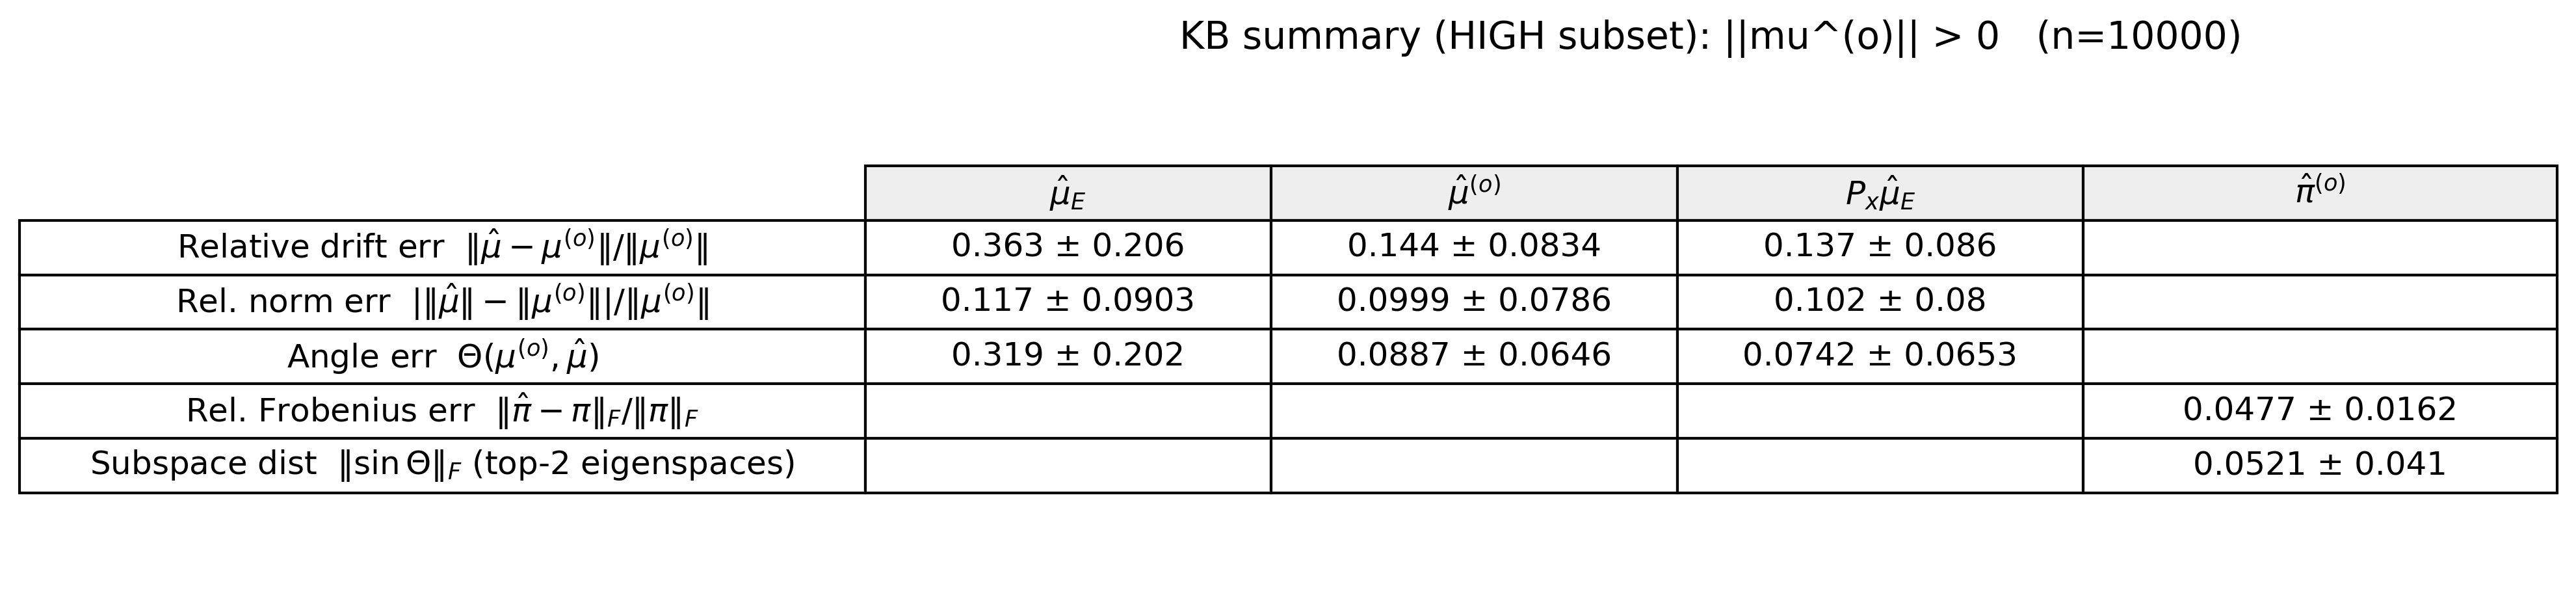

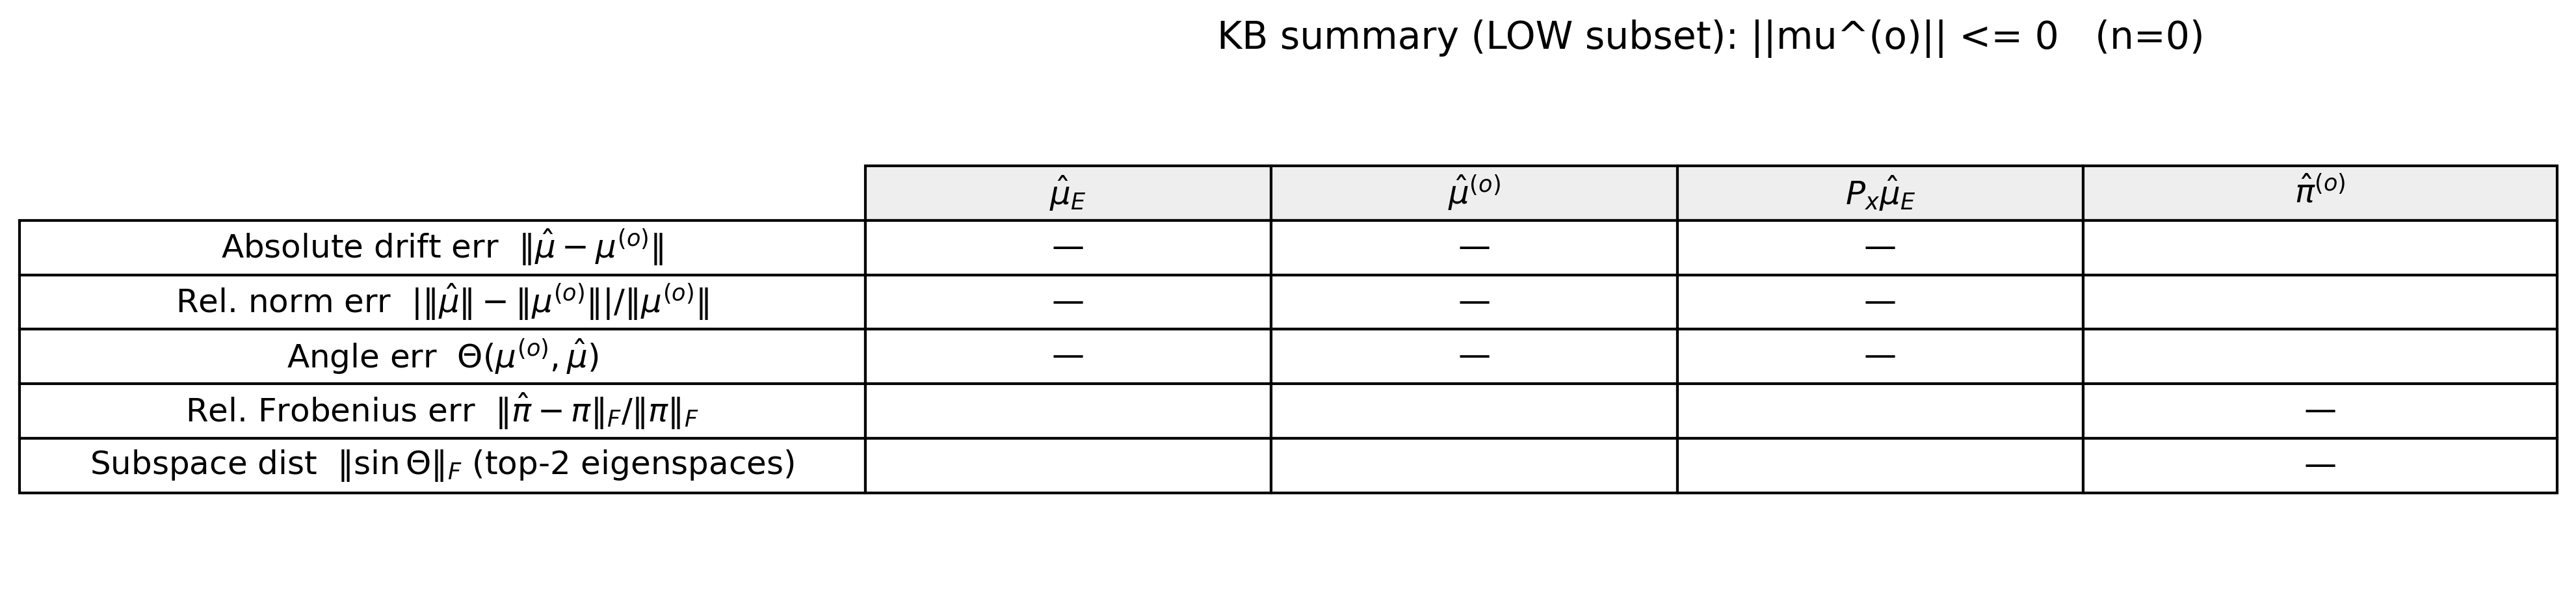

Sanity:
B total = 10000
max ||mu^(o)|| over ALL basepoints = 3.96527
ratio = 0  |  c = 0
n_high = 10000  |  n_low = 0


==== LaTeX ====

\begin{table}[t]
\centering
\renewcommand{\arraystretch}{1.1}
\begin{tabular}{lcccc}
\toprule
& $\hat{\mu}_E$ & $\hat{\mu}^{(o)}$ & $P_x\hat{\mu}_E$ & $\hat{\pi}^{(o)}$ \\
\midrule
\multicolumn{5}{l}{\textbf{HIGH subset:} $\|\mu^{(o)}(x)\|>c$} \\
\midrule
Rel drift err & 0.363 $\pm$ 0.206 & 0.144 $\pm$ 0.0834 & 0.137 $\pm$ 0.086 & --- \\
Rel norm err  & 0.117 $\pm$ 0.0903 & 0.0999 $\pm$ 0.0786 & 0.102 $\pm$ 0.08 & --- \\
Angle err     & 0.319 $\pm$ 0.202 & 0.0887 $\pm$ 0.0646 & 0.0742 $\pm$ 0.0653 & --- \\
Rel Frobenius & --- & --- & --- & 0.0477 $\pm$ 0.0162 \\
Subspace dist & --- & --- & --- & 0.0521 $\pm$ 0.041 \\
\bottomrule
\end{tabular}
\vspace{0.8em}
\begin{tabular}{lcccc}
\toprule
& $\hat{\mu}_E$ & $\hat{\mu}^{(o)}$ & $P_x\hat{\mu}_E$ & $\hat{\pi}^{(o)}$ \\
\midrule
\multicolumn{5}{l}{\textbf{LOW subset:} $\|\mu^{(o)}(x)\|\leq c$} \\
\midrule


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================
# KB summary tables split by ||mu^(o)||
#
# High subset
#   ||mu^(o)|| > c
#   Drift is summarized using relative vector error, relative norm error,
#   and angle error. Diffusion is summarized using relative Frobenius error
#   and top-2 subspace distance.
#
# Low subset
#   ||mu^(o)|| <= c
#   Drift is summarized using absolute vector error, relative norm error,
#   and angle error. Diffusion metrics are the same as above.
#
# Drift estimators
#   E   = raw ambient estimator \hat{\mu}_E
#   EE  = estimated tangent projection of \hat{\mu}_E
#   TE  = true tangent projection of \hat{\mu}_E
#
# Diffusion estimator
#   \hat{\pi}^{(o)} = estimated ambient diffusion matrix
# ============================

plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 600,
    "font.size": 13
})

eps = 1e-20

# Threshold level c is defined as ratio times the global maximum of ||mu^(o)||
# across all base points.
ratio = 0.00

# ---- load arrays from npz ----
# Shapes:
#   S = number of simulations
#   B = number of base points
#   4 = ambient dimension of the Klein bottle embedding
mu_TT_all   = np.asarray(npz["mu_proj_TT"], dtype=float)     # true tangent projection of true drift
mu_TE_all   = np.asarray(npz["mu_proj_TE"], dtype=float)     # true tangent projection of estimated drift
mu_EE_all   = np.asarray(npz["mu_proj_EE"], dtype=float)     # estimated tangent projection of estimated drift
mu_hat_all  = np.asarray(npz["mu_hat"], dtype=float)         # raw ambient drift estimate
sig_all     = np.asarray(npz["sigma_hat"], dtype=float)      # estimated ambient diffusion matrices
a = float(npz["a"])
r = float(npz["r"])

S, B, d = mu_TT_all.shape
assert d == 4, f"Expected d=4, got mu_TT_all.shape={mu_TT_all.shape}"

# Base-point coordinates in square variables (u, v).
# Newer files may store u_bp and v_bp directly.
# Older files store base_points with shape (B, 2).
if ("u_bp" in npz.files) and ("v_bp" in npz.files):
    u_all = np.asarray(npz["u_bp"], dtype=float).reshape(-1)
    v_all = np.asarray(npz["v_bp"], dtype=float).reshape(-1)
    assert u_all.shape[0] == B and v_all.shape[0] == B, f"u_bp/v_bp length mismatch: {u_all.shape}, {v_all.shape}, B={B}"
else:
    bp_uv = np.asarray(npz["base_points"], dtype=float)
    assert bp_uv.shape == (B, 2), f"Expected base_points shape (B,2); got {bp_uv.shape}"
    u_all = bp_uv[:, 0]
    v_all = bp_uv[:, 1]

# true_diffusion(u, v, a, r) is assumed to be available in the session.

# ---- reference mu^(o) ----
# Use the simulation average of the true tangent-projected drift as the reference field.
mu_true = np.nanmean(mu_TT_all, axis=0)                      # shape (B, 4)
mu_norm = np.linalg.norm(mu_true, axis=1)                    # shape (B,)

mu_norm_finite = mu_norm[np.isfinite(mu_norm)]
mu_o_inf_norm = float(np.max(mu_norm_finite)) if mu_norm_finite.size else float("nan")
c = float(mu_o_inf_norm * ratio) if np.isfinite(mu_o_inf_norm) else float("nan")

# Split base points according to the magnitude of the reference drift.
high_bp = np.isfinite(mu_norm) & (mu_norm > c)
low_bp  = np.isfinite(mu_norm) & (mu_norm <= c)
n_high = int(np.sum(high_bp))
n_low  = int(np.sum(low_bp))

# ---- Monte Carlo averages of the estimators ----
mu_hat = np.nanmean(mu_hat_all, axis=0)                      # \hat{\mu}_E
mu_TE  = np.nanmean(mu_TE_all,  axis=0)                      # P_x \hat{\mu}_E
mu_EE  = np.nanmean(mu_EE_all,  axis=0)                      # \hat{\mu}^{(o)}

# ============================
# Drift error primitives
# ============================

# Absolute vector error norms.
abs_E  = np.linalg.norm(mu_hat - mu_true, axis=1)
abs_TE = np.linalg.norm(mu_TE  - mu_true, axis=1)
abs_EE = np.linalg.norm(mu_EE  - mu_true, axis=1)

# Relative vector error norms.
den_mu = np.maximum(mu_norm, eps)
rel_E  = abs_E  / den_mu
rel_TE = abs_TE / den_mu
rel_EE = abs_EE / den_mu

# Relative norm error: | ||uhat|| - ||utrue|| | / ||utrue||
def rel_norm_err(u_hat, u_true, eps=1e-20):
    nh = np.linalg.norm(u_hat, axis=1)
    nt = np.linalg.norm(u_true, axis=1)
    return np.abs(nh - nt) / np.maximum(nt, eps)

rn_E  = rel_norm_err(mu_hat, mu_true, eps=eps)
rn_EE = rel_norm_err(mu_EE,  mu_true, eps=eps)
rn_TE = rel_norm_err(mu_TE,  mu_true, eps=eps)

# Angle error in radians.
def angle_err(u_hat, u_true, eps=1e-20):
    nh = np.linalg.norm(u_hat, axis=1)
    nt = np.linalg.norm(u_true, axis=1)
    denom = np.maximum(nh * nt, eps)
    cosang = np.sum(u_hat * u_true, axis=1) / denom
    cosang = np.clip(cosang, -1.0, 1.0)
    return np.arccos(cosang)

th_E  = angle_err(mu_hat, mu_true, eps=eps)
th_EE = angle_err(mu_EE,  mu_true, eps=eps)
th_TE = angle_err(mu_TE,  mu_true, eps=eps)

# ============================
# Diffusion metrics
# ============================
# Monte Carlo average of the estimated diffusion matrices.
Sigma_hat_avg = np.nanmean(sig_all, axis=0)                  # shape (B, 4, 4)

# True diffusion matrices at each base point.
Sigma_true = np.stack(
    [true_diffusion(ui, vi, a, r) for ui, vi in zip(u_all, v_all)],
    axis=0
)                                                            # shape (B, 4, 4)

# Relative Frobenius error per base point.
pi_diff = Sigma_hat_avg - Sigma_true
num_fro = np.linalg.norm(pi_diff.reshape(B, -1), axis=1)
den_fro = np.maximum(np.linalg.norm(Sigma_true.reshape(B, -1), axis=1), eps)
rel_fro = num_fro / den_fro

# Top-2 eigenspace comparison for diffusion matrices.
def top2_eigvecs_sym(A):
    A = 0.5*(A + A.T)
    w, V = np.linalg.eigh(A)
    idx = np.argsort(w)[::-1]
    return V[:, idx[:2]]

def subspace_dist_fro(U, V):
    M = U.T @ V
    s = np.linalg.svd(M, compute_uv=False)
    s = np.clip(s, -1.0, 1.0)
    sin2 = 1.0 - s**2
    return float(np.sqrt(np.sum(sin2)))

subdist = np.full(B, np.nan)
for i in range(B):
    Ahat = Sigma_hat_avg[i]
    Atru = Sigma_true[i]
    if not (np.all(np.isfinite(Ahat)) and np.all(np.isfinite(Atru))):
        continue
    try:
        Uhat2 = top2_eigvecs_sym(Ahat)
        Utru2 = top2_eigvecs_sym(Atru)
        subdist[i] = subspace_dist_fro(Utru2, Uhat2)
    except np.linalg.LinAlgError:
        continue

# ============================
# Split and clean arrays
# ============================
def clean(x, mask):
    x = np.asarray(x, float)
    y = x[mask]
    y = y[np.isfinite(y)]
    return y

# HIGH subset
rel_E_h   = clean(rel_E,  high_bp)
rel_EE_h  = clean(rel_EE, high_bp)
rel_TE_h  = clean(rel_TE, high_bp)

rn_E_h    = clean(rn_E,   high_bp)
rn_EE_h   = clean(rn_EE,  high_bp)
rn_TE_h   = clean(rn_TE,  high_bp)

th_E_h    = clean(th_E,   high_bp)
th_EE_h   = clean(th_EE,  high_bp)
th_TE_h   = clean(th_TE,  high_bp)

rel_fro_h = clean(rel_fro, high_bp)
sd_h      = clean(subdist, high_bp)

# LOW subset
abs_E_l   = clean(abs_E,  low_bp)
abs_EE_l  = clean(abs_EE, low_bp)
abs_TE_l  = clean(abs_TE, low_bp)

rn_E_l    = clean(rn_E,   low_bp)
rn_EE_l   = clean(rn_EE,  low_bp)
rn_TE_l   = clean(rn_TE,  low_bp)

th_E_l    = clean(th_E,   low_bp)
th_EE_l   = clean(th_EE,  low_bp)
th_TE_l   = clean(th_TE,  low_bp)

rel_fro_l = clean(rel_fro, low_bp)
sd_l      = clean(subdist, low_bp)

# ============================
# Summary statistics and formatting
# ============================
def mean_std(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return (np.nan, np.nan)
    return (float(np.mean(x)), float(np.std(x)))

def fmt_pm_text(m, s):
    if not (np.isfinite(m) and np.isfinite(s)):
        return "—"
    return f"{m:.3g} ± {s:.3g}"

def fmt_pm_latex(m, s):
    if not (np.isfinite(m) and np.isfinite(s)):
        return r"---"
    return rf"{m:.3g} $\pm$ {s:.3g}"

# Drift vector error summaries.
m_rel_E_h,  s_rel_E_h  = mean_std(rel_E_h)
m_rel_EE_h, s_rel_EE_h = mean_std(rel_EE_h)
m_rel_TE_h, s_rel_TE_h = mean_std(rel_TE_h)

m_abs_E_l,  s_abs_E_l  = mean_std(abs_E_l)
m_abs_EE_l, s_abs_EE_l = mean_std(abs_EE_l)
m_abs_TE_l, s_abs_TE_l = mean_std(abs_TE_l)

# Relative norm error summaries.
m_rn_E_h,  s_rn_E_h  = mean_std(rn_E_h)
m_rn_EE_h, s_rn_EE_h = mean_std(rn_EE_h)
m_rn_TE_h, s_rn_TE_h = mean_std(rn_TE_h)

m_rn_E_l,  s_rn_E_l  = mean_std(rn_E_l)
m_rn_EE_l, s_rn_EE_l = mean_std(rn_EE_l)
m_rn_TE_l, s_rn_TE_l = mean_std(rn_TE_l)

# Angle error summaries.
m_th_E_h,  s_th_E_h  = mean_std(th_E_h)
m_th_EE_h, s_th_EE_h = mean_std(th_EE_h)
m_th_TE_h, s_th_TE_h = mean_std(th_TE_h)

m_th_E_l,  s_th_E_l  = mean_std(th_E_l)
m_th_EE_l, s_th_EE_l = mean_std(th_EE_l)
m_th_TE_l, s_th_TE_l = mean_std(th_TE_l)

# Diffusion summaries.
m_fro_h, s_fro_h = mean_std(rel_fro_h)
m_fro_l, s_fro_l = mean_std(rel_fro_l)
m_sd_h,  s_sd_h  = mean_std(sd_h)
m_sd_l,  s_sd_l  = mean_std(sd_l)

# ============================
# Columns correspond to:
#   \hat{\mu}_E, \hat{\mu}^{(o)}, P_x\hat{\mu}_E, \hat{\pi}^{(o)}
# Rows contain drift and diffusion summaries for the selected subset.
# ============================
column_headers = [
    r"$\hat{\mu}_E$",
    r"$\hat{\mu}^{(o)}$",
    r"$P_x\hat{\mu}_E$",
    r"$\hat{\pi}^{(o)}$",
]

rows_hi, row_labels_hi = [], []
rows_lo, row_labels_lo = [], []

# HIGH subset rows
rows_hi.append([fmt_pm_text(m_rel_E_h, s_rel_E_h),
                fmt_pm_text(m_rel_EE_h, s_rel_EE_h),
                fmt_pm_text(m_rel_TE_h, s_rel_TE_h),
                ""])
row_labels_hi.append(r"Relative drift err  $\|\hat\mu-\mu^{(o)}\|/\|\mu^{(o)}\|$")

rows_hi.append([fmt_pm_text(m_rn_E_h, s_rn_E_h),
                fmt_pm_text(m_rn_EE_h, s_rn_EE_h),
                fmt_pm_text(m_rn_TE_h, s_rn_TE_h),
                ""])
row_labels_hi.append(r"Rel. norm err  $|\|\hat\mu\|-\|\mu^{(o)}\||/\|\mu^{(o)}\|$")

rows_hi.append([fmt_pm_text(m_th_E_h, s_th_E_h),
                fmt_pm_text(m_th_EE_h, s_th_EE_h),
                fmt_pm_text(m_th_TE_h, s_th_TE_h),
                ""])
row_labels_hi.append(r"Angle err  $\Theta(\mu^{(o)},\hat\mu)$")

rows_hi.append(["", "", "", fmt_pm_text(m_fro_h, s_fro_h)])
row_labels_hi.append(r"Rel. Frobenius err  $\|\hat\pi-\pi\|_F/\|\pi\|_F$")

rows_hi.append(["", "", "", fmt_pm_text(m_sd_h, s_sd_h)])
row_labels_hi.append(r"Subspace dist  $\|\sin\Theta\|_F$ (top-2 eigenspaces)")

# LOW subset rows
rows_lo.append([fmt_pm_text(m_abs_E_l, s_abs_E_l),
                fmt_pm_text(m_abs_EE_l, s_abs_EE_l),
                fmt_pm_text(m_abs_TE_l, s_abs_TE_l),
                ""])
row_labels_lo.append(r"Absolute drift err  $\|\hat\mu-\mu^{(o)}\|$")

rows_lo.append([fmt_pm_text(m_rn_E_l, s_rn_E_l),
                fmt_pm_text(m_rn_EE_l, s_rn_EE_l),
                fmt_pm_text(m_rn_TE_l, s_rn_TE_l),
                ""])
row_labels_lo.append(r"Rel. norm err  $|\|\hat\mu\|-\|\mu^{(o)}\||/\|\mu^{(o)}\|$")

rows_lo.append([fmt_pm_text(m_th_E_l, s_th_E_l),
                fmt_pm_text(m_th_EE_l, s_th_EE_l),
                fmt_pm_text(m_th_TE_l, s_th_TE_l),
                ""])
row_labels_lo.append(r"Angle err  $\Theta(\mu^{(o)},\hat\mu)$")

rows_lo.append(["", "", "", fmt_pm_text(m_fro_l, s_fro_l)])
row_labels_lo.append(r"Rel. Frobenius err  $\|\hat\pi-\pi\|_F/\|\pi\|_F$")

rows_lo.append(["", "", "", fmt_pm_text(m_sd_l, s_sd_l)])
row_labels_lo.append(r"Subspace dist  $\|\sin\Theta\|_F$ (top-2 eigenspaces)")

def render_table(rows, row_labels, col_labels, col_widths, title=None):
    fig_h = max(3.2, 0.65 * len(rows))
    fig, ax = plt.subplots(figsize=(13.6, fig_h))
    ax.axis("off")
    table = ax.table(
        cellText=rows,
        rowLabels=row_labels,
        colLabels=col_labels,
        cellLoc="center",
        rowLoc="center",
        loc="center",
        colWidths=col_widths
    )
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1.08, 1.65)
    for (rr, cc), cell in table.get_celld().items():
        cell.set_edgecolor("black")
        cell.set_linewidth(1.0)
        if rr == 0:
            cell.set_text_props(weight="bold")
            cell.set_facecolor("#EEEEEE")
    if title:
        ax.set_title(title, pad=12, fontsize=14)
    plt.tight_layout()
    plt.show()

render_table(
    rows_hi, row_labels_hi, column_headers,
    [0.24, 0.24, 0.24, 0.28],
    title=f"KB summary (HIGH subset): ||mu^(o)|| > {c:g}   (n={n_high})"
)

render_table(
    rows_lo, row_labels_lo, column_headers,
    [0.24, 0.24, 0.24, 0.28],
    title=f"KB summary (LOW subset): ||mu^(o)|| <= {c:g}   (n={n_low})"
)

print("Sanity:")
print(f"B total = {B}")
print(f"max ||mu^(o)|| over ALL basepoints = {mu_o_inf_norm:.6g}")
print(f"ratio = {ratio:g}  |  c = {c:.6g}")
print(f"n_high = {n_high}  |  n_low = {n_low}")

# ============================
# LaTeX output
# Generates a two-part table with separate HIGH and LOW subsets.
# The diffusion column is retained as \hat{\pi}^{(o)}.
# ============================
latex = []
latex.append(r"\begin{table}[t]")
latex.append(r"\centering")
latex.append(r"\renewcommand{\arraystretch}{1.1}")

latex.append(r"\begin{tabular}{lcccc}")
latex.append(r"\toprule")
latex.append(r"& $\hat{\mu}_E$ & $\hat{\mu}^{(o)}$ & $P_x\hat{\mu}_E$ & $\hat{\pi}^{(o)}$ \\")
latex.append(r"\midrule")
latex.append(rf"\multicolumn{{5}}{{l}}{{\textbf{{HIGH subset:}} $\|\mu^{{(o)}}(x)\|>c$}} \\")
latex.append(r"\midrule")
latex.append(rf"Rel drift err & {fmt_pm_latex(m_rel_E_h,s_rel_E_h)} & {fmt_pm_latex(m_rel_EE_h,s_rel_EE_h)} & {fmt_pm_latex(m_rel_TE_h,s_rel_TE_h)} & --- \\")
latex.append(rf"Rel norm err  & {fmt_pm_latex(m_rn_E_h,s_rn_E_h)} & {fmt_pm_latex(m_rn_EE_h,s_rn_EE_h)} & {fmt_pm_latex(m_rn_TE_h,s_rn_TE_h)} & --- \\")
latex.append(rf"Angle err     & {fmt_pm_latex(m_th_E_h,s_th_E_h)} & {fmt_pm_latex(m_th_EE_h,s_th_EE_h)} & {fmt_pm_latex(m_th_TE_h,s_th_TE_h)} & --- \\")
latex.append(rf"Rel Frobenius & --- & --- & --- & {fmt_pm_latex(m_fro_h,s_fro_h)} \\")
latex.append(rf"Subspace dist & --- & --- & --- & {fmt_pm_latex(m_sd_h,s_sd_h)} \\")
latex.append(r"\bottomrule")
latex.append(r"\end{tabular}")

latex.append(r"\vspace{0.8em}")

latex.append(r"\begin{tabular}{lcccc}")
latex.append(r"\toprule")
latex.append(r"& $\hat{\mu}_E$ & $\hat{\mu}^{(o)}$ & $P_x\hat{\mu}_E$ & $\hat{\pi}^{(o)}$ \\")
latex.append(r"\midrule")
latex.append(rf"\multicolumn{{5}}{{l}}{{\textbf{{LOW subset:}} $\|\mu^{{(o)}}(x)\|\leq c$}} \\")
latex.append(r"\midrule")
latex.append(rf"Abs drift err & {fmt_pm_latex(m_abs_E_l,s_abs_E_l)} & {fmt_pm_latex(m_abs_EE_l,s_abs_EE_l)} & {fmt_pm_latex(m_abs_TE_l,s_abs_TE_l)} & --- \\")
latex.append(rf"Rel norm err  & {fmt_pm_latex(m_rn_E_l,s_rn_E_l)} & {fmt_pm_latex(m_rn_EE_l,s_rn_EE_l)} & {fmt_pm_latex(m_rn_TE_l,s_rn_TE_l)} & --- \\")
latex.append(rf"Angle err     & {fmt_pm_latex(m_th_E_l,s_th_E_l)} & {fmt_pm_latex(m_th_EE_l,s_th_EE_l)} & {fmt_pm_latex(m_th_TE_l,s_th_TE_l)} & --- \\")
latex.append(rf"Rel Frobenius & --- & --- & --- & {fmt_pm_latex(m_fro_l,s_fro_l)} \\")
latex.append(rf"Subspace dist & --- & --- & --- & {fmt_pm_latex(m_sd_l,s_sd_l)} \\")
latex.append(r"\bottomrule")
latex.append(r"\end{tabular}")

latex.append(
    rf"\caption{{KB summary split by $\|\mu^{{(o)}}(x)\|>c$, where $c={ratio:g}\max_x\|\mu^{{(o)}}(x)\|$. "
    rf"Drift reports vector error (relative in HIGH, absolute in LOW), plus relative norm error and angle error. "
    rf"Diffusion reports relative Frobenius error and the subspace distance between the dominant 2D eigenspaces of $\hat\pi$ and $\pi$ via $\|\sin\Theta\|_F$.}}"
)
latex.append(r"\label{tab:obskb_summary_with_fro_and_subspace}")
latex.append(r"\end{table}")

print("\n\n==== LaTeX ====\n")
print("\n".join(latex))

In [ ]:
import numpy as np
from scipy.stats import wilcoxon

ALPHA = 0.05

# -----------------------------
# Utilities
# -----------------------------
def paired_clean(a, b):
    a = np.asarray(a, float).ravel()
    b = np.asarray(b, float).ravel()
    ok = np.isfinite(a) & np.isfinite(b)
    a, b = a[ok], b[ok]
    d = a - b
    nz = d != 0.0
    return a[nz], b[nz]

def fmt(p):
    if p is None or (not np.isfinite(p)):
        return "nan"
    return f"{p:.3e}" if p < 1e-3 else f"{p:.4f}"

def run_two_tests(err_E, err_EE, err_TE, label):
    """
    Paired Wilcoxon signed-rank tests for expected ordering:
        TE < EE < E
    on a chosen scalar error metric (one value per basepoint).
    """
    err_E  = np.asarray(err_E,  dtype=float).ravel()
    err_EE = np.asarray(err_EE, dtype=float).ravel()
    err_TE = np.asarray(err_TE, dtype=float).ravel()

    # Test 1: TE < EE
    a1, b1 = paired_clean(err_TE, err_EE)
    p1 = wilcoxon(a1, b1, alternative="less").pvalue if a1.size else np.nan

    # Test 2: EE < E
    a2, b2 = paired_clean(err_EE, err_E)
    p2 = wilcoxon(a2, b2, alternative="less").pvalue if a2.size else np.nan

    alpha_B = ALPHA / 2.0
    p1_adj = min(1.0, 2.0 * p1) if np.isfinite(p1) else np.nan
    p2_adj = min(1.0, 2.0 * p2) if np.isfinite(p2) else np.nan

    mE  = float(np.nanmean(err_E))  if err_E.size  else np.nan
    mEE = float(np.nanmean(err_EE)) if err_EE.size else np.nan
    mTE = float(np.nanmean(err_TE)) if err_TE.size else np.nan

    ok1 = np.isfinite(p1_adj) and (p1_adj < alpha_B)
    ok2 = np.isfinite(p2_adj) and (p2_adj < alpha_B)

    print("=" * 78)
    print(label)
    print(f"n_eff(TE vs EE) = {a1.size}   n_eff(EE vs E) = {a2.size}")
    print(f"means:  E={mE:.4g},  EE={mEE:.4g},  TE={mTE:.4g}")
    print(f"TEST 1 (one-sided):  TE < EE     p={fmt(p1)}   p_adj={fmt(p1_adj)}   alpha_B={alpha_B:g}")
    print(f"TEST 2 (one-sided):  EE < E      p={fmt(p2)}   p_adj={fmt(p2_adj)}   alpha_B={alpha_B:g}")
    if ok1 and ok2:
        print("CONCLUSION: supports ordering  TE < EE < E  (Bonferroni-corrected).")
    else:
        parts = []
        parts.append("TE < EE" if ok1 else "TE < EE not significant")
        parts.append("EE < E"  if ok2 else "EE < E not significant")
        print("CONCLUSION:", "; ".join(parts))

# -----------------------------
# Build additional drift metrics (per basepoint)
# Required from the split-by-c cell:
#   high_bp, low_bp (boolean masks over ALL basepoints B)
#   mu_true (B,4), mu_hat (B,4), mu_EE (B,4), mu_TE (B,4)
#   mu_norm (B,)
# and yotheur eps definition
# -----------------------------
need = ["high_bp","low_bp","mu_true","mu_hat","mu_EE","mu_TE","mu_norm","eps"]
missing = [k for k in need if k not in globals()]
if missing:
    raise NameError(f"Missing {missing}. Run the split-by-c table cell first.")

mu_true_all = np.asarray(mu_true, float)
mu_E_all    = np.asarray(mu_hat, float)   # \hat{\mu}_E
mu_EE_all   = np.asarray(mu_EE, float)    # \hat{\mu}^{(o)}
mu_TE_all   = np.asarray(mu_TE, float)    # P_x \hat{\mu}_E
mu_norm_all = np.asarray(mu_norm, float)
den_mu_all  = np.maximum(mu_norm_all, eps)

# --- (A) existing vector relative error (NRMSE-style): ||est-true|| / ||true||
relvec_E_all  = np.linalg.norm(mu_E_all  - mu_true_all, axis=1) / den_mu_all
relvec_EE_all = np.linalg.norm(mu_EE_all - mu_true_all, axis=1) / den_mu_all
relvec_TE_all = np.linalg.norm(mu_TE_all - mu_true_all, axis=1) / den_mu_all

# --- (B) relative norm error: | ||est|| - ||true|| | / ||true||
norm_true = np.linalg.norm(mu_true_all, axis=1)
norm_E    = np.linalg.norm(mu_E_all,    axis=1)
norm_EE   = np.linalg.norm(mu_EE_all,   axis=1)
norm_TE   = np.linalg.norm(mu_TE_all,   axis=1)

relnorm_E_all  = np.abs(norm_E  - norm_true) / den_mu_all
relnorm_EE_all = np.abs(norm_EE - norm_true) / den_mu_all
relnorm_TE_all = np.abs(norm_TE - norm_true) / den_mu_all

# --- (C) angle error: theta(u_true, u_hat) in radians
# use arccos( <a,b> / (||a|| ||b||) ), guarded
def angle_err(a, b, eps=1e-20):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    na = np.linalg.norm(a, axis=1)
    nb = np.linalg.norm(b, axis=1)
    denom = np.maximum(na * nb, eps)
    cosang = np.sum(a*b, axis=1) / denom
    cosang = np.clip(cosang, -1.0, 1.0)
    return np.arccos(cosang)

ang_E_all  = angle_err(mu_true_all, mu_E_all,  eps=eps)
ang_EE_all = angle_err(mu_true_all, mu_EE_all, eps=eps)
ang_TE_all = angle_err(mu_true_all, mu_TE_all, eps=eps)

# -----------------------------
# Run Wilcoxon tests on BOTH subsets, for each metric
# HIGH subset: use relative-type metrics (relvec, relnorm, angle)
# LOW subset:  use absolute-type metrics where appropriate.
#   - For relnorm: denominator uses ||mu_true||, but low subset can have tiny norms.
#     So for LOW we typically prefer ABS norm error: | ||est|| - ||true|| |
#   - For angle: undefined-ish when ||mu_true|| ~ 0; we still compute, but we may
#     want to drop very small ||mu_true|| points. Here we keep finite-only.
# -----------------------------
high = np.asarray(high_bp, bool)
low  = np.asarray(low_bp, bool)

# existing "absolute drift error" metric: ||est-true||
absvec_E_all  = np.linalg.norm(mu_E_all  - mu_true_all, axis=1)
absvec_EE_all = np.linalg.norm(mu_EE_all - mu_true_all, axis=1)
absvec_TE_all = np.linalg.norm(mu_TE_all - mu_true_all, axis=1)

# absolute norm error: | ||est|| - ||true|| |
absnorm_E_all  = np.abs(norm_E  - norm_true)
absnorm_EE_all = np.abs(norm_EE - norm_true)
absnorm_TE_all = np.abs(norm_TE - norm_true)

# (1) Vector error
run_two_tests(relvec_E_all[high],  relvec_EE_all[high],  relvec_TE_all[high],
              label="KB HIGH subset: relative vector error  ||est-true||/||true||")
run_two_tests(absvec_E_all[low],   absvec_EE_all[low],   absvec_TE_all[low],
              label="KB LOW subset: absolute vector error  ||est-true||")

# (2) Relative/absolute norm error
run_two_tests(relnorm_E_all[high], relnorm_EE_all[high], relnorm_TE_all[high],
              label="KB HIGH subset: relative norm error  | ||est||-||true|| | / ||true||")
run_two_tests(absnorm_E_all[low],  absnorm_EE_all[low],  absnorm_TE_all[low],
              label="KB LOW subset: absolute norm error  | ||est||-||true|| |")

# (3) Angle error (radians)
# For LOW, can still test angles; it’s just less meaningful if ||mu_true||≈0.
# Here we run it anyway; it will automatically drop NaNs/Infs.
run_two_tests(ang_E_all[high],  ang_EE_all[high],  ang_TE_all[high],
              label="KB HIGH subset: angle error  theta(mu_true, mu_est) [radians]")
run_two_tests(ang_E_all[low],   ang_EE_all[low],   ang_TE_all[low],
              label="KB LOW subset: angle error  theta(mu_true, mu_est) [radians]")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

eps = 1e-12

# ============================================================
# Use NON-_d arrays already in memory (NO filtering)
# Requires:
#   mu_proj_TT_all, mu_proj_TE_all, mu_proj_EE_all, mu_hat_all : (S,B,4)
# ============================================================

mu_TT_all  = np.asarray(mu_proj_TT_all, dtype=float)   # (S,B,4) reference mu^(o)
mu_TE_all  = np.asarray(mu_proj_TE_all, dtype=float)   # (S,B,4) P \hat{mu}_E
mu_EE_all  = np.asarray(mu_proj_EE_all, dtype=float)   # (S,B,4) \hat{mu}^{(o)}
mu_hat_all = np.asarray(mu_hat_all,    dtype=float)    # (S,B,4) \hat{mu}_E

# MC-averages (B,4)
mu_true = np.nanmean(mu_TT_all,  axis=0)
mu_TE   = np.nanmean(mu_TE_all,  axis=0)
mu_EE   = np.nanmean(mu_EE_all,  axis=0)
mu_E    = np.nanmean(mu_hat_all, axis=0)

# Align lengths defensively
n = min(len(mu_true), len(mu_E), len(mu_TE), len(mu_EE))
mu_true = mu_true[:n]
mu_E    = mu_E[:n]
mu_TE   = mu_TE[:n]
mu_EE   = mu_EE[:n]

den = np.maximum(np.linalg.norm(mu_true, axis=1), eps)

# Metric: ||mu_est - mu_true|| / ||mu_true||
err_E  = np.linalg.norm(mu_E  - mu_true, axis=1) / den
err_TE = np.linalg.norm(mu_TE - mu_true, axis=1) / den
err_EE = np.linalg.norm(mu_EE - mu_true, axis=1) / den

err_E  = err_E[np.isfinite(err_E)]
err_TE = err_TE[np.isfinite(err_TE)]
err_EE = err_EE[np.isfinite(err_EE)]

# ---- plotting (match the drift-hist style)
plt.rcParams["figure.dpi"] = 300
plt.rcParams["savefig.dpi"] = 300
plt.rcParams.update({
    "font.size": 13,
    "axes.labelsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

bins = 30

m_E  = float(np.mean(err_E))
m_TE = float(np.mean(err_TE))
m_EE = float(np.mean(err_EE))

fig, ax = plt.subplots(figsize=(8.0, 4.2), constrained_layout=True)
ax.tick_params(axis="both", which="major", labelsize=12, length=6, width=1.2)

ax.hist(err_E,  bins=bins, density=True, alpha=0.5, color="tab:red")
ax.hist(err_EE, bins=bins, density=True, alpha=0.5, color="tab:blue")
ax.hist(err_TE, bins=bins, density=True, alpha=0.5, color="tab:orange")

ax.axvline(m_E,  color="tab:red",    linestyle="--", linewidth=2)
ax.axvline(m_EE, color="tab:blue",   linestyle="--", linewidth=2)
ax.axvline(m_TE, color="tab:orange", linestyle="--", linewidth=2)

upper = float(max(err_E.max(), err_TE.max(), err_EE.max()))
ax.set_xlim(0.0, 1.05 * upper)

ax.set_xlabel("Relative error")
ax.set_ylabel("Density")

handles = [
    Line2D([0],[0], color="tab:red",    lw=6, alpha=0.7, label=r"$\hat{\mu}_E$"),
    Line2D([0],[0], color="tab:blue",   lw=6, alpha=0.7, label=r"$\hat{\mu}^{(o)}$"),
    Line2D([0],[0], color="tab:orange", lw=6, alpha=0.7, label=r"$P\,\hat{\mu}_E$"),
    Line2D([0],[0], color="k",          lw=2, linestyle="--", label="mean"),
]
fig.legend(handles=handles, loc="upper center", ncol=4, frameon=False,
           fontsize=12, bbox_to_anchor=(0.5, 1.08))

plt.show()

In [ ]:
# ============================================================
# Histogram: Relative Frobenius Error (Diffusion)  [KB]
#   Style matches the drift-hist format:
#     - same rcParams / tick params
#     - constrained_layout
#     - figure-level legend at top
#     - ONLY legend entry explains dashed mean line
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ---- assumes the load cell already ran and these exist:
#   pi_hat_avg_all : (B,4,4)   MC-avg sigma_hat over sims
#   u_bp_all, v_bp_all : (B,)  basepoints (not used here, but loaded)
#   a, r : floats
# and we still have access to the KB geometry helper(s) that define the true diffusion.

# If we already have true_diffusion(u,v,a,r) imported, keep this.
# Otherwise define it here consistently with our SDE_sample_KB:
def klein_jacobian(u, v, a, r):
    Ju = np.array([
        -np.sin(u) * (a + r * np.cos(v)),
         np.cos(u) * (a + r * np.cos(v)),
        -0.5 * r * np.sin(u / 2.0) * np.sin(v),
         0.5 * r * np.cos(u / 2.0) * np.sin(v)
    ])
    Jv = np.array([
        -r * np.cos(u) * np.sin(v),
        -r * np.sin(u) * np.sin(v),
         r * np.cos(u / 2.0) * np.cos(v),
         r * np.sin(u / 2.0) * np.cos(v)
    ])
    return np.column_stack((Ju, Jv))  # (4,2)

def true_diffusion(u, v, a, r):
    J = klein_jacobian(u, v, a, r)
    return J @ J.T  # (4,4)

# ---- compute true diffusion at all basepoints
B = base_points_all.shape[0]
pi_true_all = np.zeros((B, 4, 4), dtype=float)
for i in range(B):
    u, v = base_points_all[i]
    pi_true_all[i] = true_diffusion(u, v, a, r)

# ---- relative Frobenius error at each basepoint
diff = pi_hat_avg_all - pi_true_all                       # (B,4,4)
num = np.linalg.norm(diff.reshape(B, -1), axis=1)         # (B,)
den = np.linalg.norm(pi_true_all.reshape(B, -1), axis=1)  # (B,)
rel_fro_err = num / (den + 1e-12)
rel_fro_err = rel_fro_err[np.isfinite(rel_fro_err)]

# ---- plotting
plt.rcParams["figure.dpi"] = 300
plt.rcParams["savefig.dpi"] = 300
plt.rcParams.update({
    "font.size": 13,
    "axes.labelsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

bins = 30
c_pi = "tab:purple"
mean_rel_fro = float(np.mean(rel_fro_err))

fig, ax = plt.subplots(figsize=(8.0, 4.2), constrained_layout=True)
ax.tick_params(axis="both", which="major", labelsize=12, length=6, width=1.2)

ax.hist(rel_fro_err, bins=bins, density=True, alpha=0.5, color=c_pi)
ax.axvline(mean_rel_fro, color=c_pi, linestyle="--", linewidth=2)

upper = float(rel_fro_err.max())
ax.set_xlim(0.0, 1.05 * upper)

ax.set_xlabel("Relative Frobenius error")
ax.set_ylabel("Density")

# legend: ONLY explain the dashed line
handles = [Line2D([0],[0], color="k", lw=2, linestyle="--", label="mean")]
fig.legend(handles=handles, loc="upper center", ncol=1, frameon=False,
           fontsize=12, bbox_to_anchor=(0.5, 1.08))

plt.show()

In [ ]:
from google.colab import files
files.upload()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# PARAMETERS (must match)
# -----------------------
a = 2.0
r = 1.0

# -----------------------
# LOAD (latent square histogram)
# -----------------------
data = np.load("obsKB_exp3_density_JOB318023_N100000000_Delta0.01_grid120x120.npz")

densities   = data["densities"]     # (K, n_u, n_v)
u_edges     = data["u_edges"]
v_edges     = data["v_edges"]
checkpoints = data["checkpoints"]
n_u         = int(np.asarray(data["n_u"]).item())
n_v         = int(np.asarray(data["n_v"]).item())

du = float(u_edges[1] - u_edges[0])
dv = float(v_edges[1] - v_edges[0])

# Delta (prefer stored value; otherwise fall back to 1/sqrt(N_max))
if "Delta" in data.files:
    Delta = float(np.asarray(data["Delta"]).item())
else:
    N_max = int(np.max(checkpoints))
    Delta = N_max ** (-0.5)

# -----------------------
# GEOMETRY: area element sqrt(det(J^T J)) on bin-centers
# -----------------------
u_centers = 0.5 * (u_edges[:-1] + u_edges[1:])
v_centers = 0.5 * (v_edges[:-1] + v_edges[1:])

J_det = np.zeros((n_u, n_v), dtype=float)
for i, u in enumerate(u_centers):
    for j, v in enumerate(v_centers):
        J = klein_jacobian(float(u), float(v), a, r)   # (4,2)
        G = J.T @ J                                    # (2,2)
        J_det[i, j] = np.sqrt(np.linalg.det(G))

# -----------------------
# CONVERT latent -> observed surface density and renormalize
# -----------------------
observed = densities / J_det[None, :, :]
area_element = J_det * du * dv
for k in range(len(checkpoints)):
    total_mass = np.sum(observed[k] * area_element)
    observed[k] /= total_mass

# -----------------------
# PLOT (per-panel colorbar; NOT shared) — title uses T = Delta * N
#   NEW: fewer ticks, bigger font
# -----------------------
plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "font.size": 18,
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
})

mask = checkpoints >= 10_000
Ns = checkpoints[mask]
obs_list = observed[mask]
if len(Ns) == 0:
    raise ValueError("No checkpoints >= 10,000 found.")

fig, axes = plt.subplots(
    1, len(Ns),
    figsize=(5.0 * len(Ns), 4.8),
    constrained_layout=True
)
if len(Ns) == 1:
    axes = [axes]

extent = [float(u_edges[0]), float(u_edges[-1]), float(v_edges[0]), float(v_edges[-1])]

# fewer ticks: just 0, pi, 2pi
ticks = [0.0, np.pi, 2*np.pi]
ticklabels = [r"$0$", r"$\pi$", r"$2\pi$"]

for ax, N, rho in zip(axes, Ns, obs_list):
    im = ax.imshow(
        rho.T,
        origin="lower",
        extent=extent,
        aspect="equal",
    )
    T = Delta * float(N)
    #ax.set_title(f"T = {T:.3g}", pad=10)
    ax.set_xlabel("u")
    ax.set_ylabel("v")

    ax.set_xticks(ticks); ax.set_xticklabels(ticklabels)
    ax.set_yticks(ticks); ax.set_yticklabels(ticklabels)

    ax.tick_params(axis="both", length=6, width=1.2)

    #cbar = fig.colorbar(im, ax=ax, shrink=0.85)
    #cbar.ax.tick_params(labelsize=16)

plt.show()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Expected in memory from previous cell:
# observed      : (K, n_u, n_v)  observed surface densities
# checkpoints   : (K,)
# u_edges, v_edges
# J_det         : (n_u, n_v)  = sqrt(det(J^T J)) at bin centers
# du, dv

densities = observed
K = len(checkpoints)

# final snapshot as convergence proxy
rho_final = densities[-1]

# L2 errors with surface measure
l2_errors = []
for k in range(K - 1):
    diff = densities[k] - rho_final
    l2 = np.sqrt(np.sum(diff**2 * J_det) * du * dv)
    l2_errors.append(l2)

Ns = np.asarray(checkpoints[:-1], dtype=float)
l2_errors = np.asarray(l2_errors, dtype=float)

# keep only positive finite points for loglog + fit
good = (Ns > 0) & np.isfinite(l2_errors) & (l2_errors > 0)
Ns_fit = Ns[good]
E_fit  = l2_errors[good]

# log-log fit
logN = np.log(Ns_fit)
logE = np.log(E_fit)
slope, intercept = np.polyfit(logN, logE, 1)
fit_line = np.exp(intercept) * Ns_fit**slope

# plot
plt.rcParams["figure.dpi"] = 300
plt.rcParams["savefig.dpi"] = 300

plt.figure(figsize=(6.5, 4.8))
plt.loglog(Ns_fit, E_fit, "o-", linewidth=2.5, markersize=6, label="Empirical error")
plt.loglog(Ns_fit, fit_line, "--", linewidth=2, label=rf"Fit: $\sim n^{{{slope:.2f}}}$")

plt.xlabel("n", fontsize=14)
plt.ylabel(r"$\|\hat{L}^{(o)} - \phi_X\|_{L^2(\varphi(\mathcal{S}))}$", fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.legend(fontsize=12, frameon=False)
plt.tight_layout()
plt.show()

print("Estimated convergence rate:", slope)